In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/maimaumme/bangla-cyberbullying/pattern lab dataset.xlsx


# Libraries

In [2]:
# Basic libraries
import os
import numpy as np
import pandas as pd


# Inter-rater agreement
from statsmodels.stats.inter_rater import fleiss_kappa

# Train-test split & label encoding
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder


# Optional: metrics for evaluation
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Dataset Collection & Load

In [3]:
# Load dataset
file_path = '/kaggle/input/datasets/maimaumme/bangla-cyberbullying/pattern lab dataset.xlsx'
df = pd.read_excel(file_path)

# Inspect dataset
df.head()

,Unnamed: 0,Description,Label,Annotation 1,Annotation 2,Annotation 3
0,0.0,ওই হালার পুত এখন কি মদ খাওয়ার সময় রাতের বেলা...,sexual,sexualized vulgar,sexualized vulgar,Sexualized Vulgar
1,1.0,আপনার জন্ম প্রক্রিয়ার সময় আপনার মায়ের ভিতর কি ...,sexual,Sexualized Vulgar,Sexualized Vulgar,Sexualized Vulgar
2,2.0,বোকাচোদা একটা।,sexual,Personal Attack,Personal Attack,Personal Attack
3,3.0,নিজের রিভিউ বারানোর জন্যই জতো সব নাটক? ফালতু.....,sexual,Personal Attack,Personal Attack,Personal Attack
4,4.0,আমাদের দেশের পোলাপাইনদের কোন কাজকাম নাই মনে ...,sexual,sexualized vulgar,sexualized vulgar,sexualized vulgar


# Subclass Design & Preprocessing

In [9]:
# Rename annotation columns
df = df.rename(columns={
    'Annotation 1': 'annotator1',
    'Annotation 2': 'annotator2',
    'Annotation 3': 'annotator3'
})

# Standardize text
for col in ['annotator1', 'annotator2', 'annotator3']:
    df[col] = df[col].str.lower().str.strip()

# Drop rows with missing labels
df = df.dropna()

# Define all subclasses (fine-grained)
subclasses = [
    'sexualized vulgar', 'sexual objectification', 'personal attack', 'sexualized slur',
    'violent', 'indirect threat', 'direct threat',
    'political criticism', 'political insult', 'political accusation', 'political threat',
    'provocation', 'opinionated', 'insulting', 'sarcasm',
    'neutral inquiry', 'information', 'appreciate', 'supportive', 'positive', 'advice', 'opinion'
]

# Label Quality Check (Fleiss Kappa)

In [18]:
# Build matrix for Fleiss Kappa
matrix = []
for _, row in df.iterrows():
    counts = [0] * len(subclasses)
    labels = [row['annotator1'], row['annotator2'], row['annotator3']]
    for label in labels:
        if label in subclasses:
            idx = subclasses.index(label)
            counts[idx] += 1
    matrix.append(counts)

matrix_df = pd.DataFrame(matrix, columns=subclasses)

import pandas as pd
from statsmodels.stats.inter_rater import fleiss_kappa

# ---- Identify problematic rows ----
problem_rows = matrix_df[matrix_df.sum(axis=1) != 3]

print("Number of problematic rows:", len(problem_rows))
print(problem_rows)

# ---- Drop problematic rows ----
matrix_df = matrix_df[matrix_df.sum(axis=1) == 3].reset_index(drop=True)

# ---- Verify ----
print("\nAfter cleaning:")
print("Remaining rows:", len(matrix_df))
print("Row sums:", matrix_df.sum(axis=1).unique())

# ---- Compute Fleiss Kappa ----
kappa = fleiss_kappa(matrix_df.values)
print("\nFleiss Kappa:", kappa)

Number of problematic rows: 2
     sexualized vulgar  sexual objectification  personal attack  \
40                   0                       0                0   
156                  0                       0                0   

     sexualized slur  violent  indirect threat  direct threat  \
40                 0        0                0              0   
156                0        0                0              0   

     political criticism  political insult  political accusation  ...  \
40                     0                 0                     0  ...   
156                    0                 0                     0  ...   

     opinionated  insulting  sarcasm  neutral inquiry  information  \
40             0          0        0                0            0   
156            0          0        0                0            0   

     appreciate  supportive  positive  advice  opinion  
40            0           0         0       0        0  
156           0           0

# Majority Voting (Final Label)

In [19]:
# Function to assign final label using majority vote
def majority_vote(row):
    labels = [row['annotator1'], row['annotator2'], row['annotator3']]
    return max(set(labels), key=labels.count)

# Apply function
df['final_label'] = df.apply(majority_vote, axis=1)

# Check first 5 rows
df[['Description', 'final_label']].head()

,Description,final_label
0,ওই হালার পুত এখন কি মদ খাওয়ার সময় রাতের বেলা...,sexualized vulgar
1,আপনার জন্ম প্রক্রিয়ার সময় আপনার মায়ের ভিতর কি ...,sexualized vulgar
2,বোকাচোদা একটা।,personal attack
3,নিজের রিভিউ বারানোর জন্যই জতো সব নাটক? ফালতু.....,personal attack
4,আমাদের দেশের পোলাপাইনদের কোন কাজকাম নাই মনে ...,sexualized vulgar


# Merge Rare Labels

In [20]:
df['final_label'] = df['final_label'].replace({
    'sexualized vulger': 'sexualized vulgar',
    'sxualized vulgar': 'sexualized vulgar'
})

In [21]:
df['final_label'].unique()
df['final_label'].value_counts()

final_label
sexualized vulgar         157
insulting                  93
sarcasm                    80
positive                   69
violent                    60
supportive                 50
appreciate                 50
opinion                    49
provocation                45
personal attack            45
political insult           45
neutral inquiry            39
opinionated                38
sexual objectification     31
political criticism        31
political accusation       24
information                22
indirect threat            22
advice                     22
direct threat              19
sexualized slur            17
political threat           12
Name: count, dtype: int64

# Train / Validation / Test Split, Encode & Save

In [22]:
# ==========================================
# FULL PIPELINE: Split + Encode + Save (Excel)
# ==========================================

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# ======================
# 1. Stratified Split
# ======================
train_df, test_df = train_test_split(
    df,
    test_size=0.2,
    random_state=42,
    stratify=df['final_label']
)

train_df, val_df = train_test_split(
    train_df,
    test_size=0.1,
    random_state=42,
    stratify=train_df['final_label']
)

# ======================
# 2. Label Encoding
# ======================
all_labels = np.concatenate([
    train_df['final_label'].values,
    val_df['final_label'].values,
    test_df['final_label'].values
])

le = LabelEncoder()
le.fit(all_labels)

train_df['label'] = le.transform(train_df['final_label'])
val_df['label'] = le.transform(val_df['final_label'])
test_df['label'] = le.transform(test_df['final_label'])

# ======================
# 3. Save as Excel
# ======================

# Option A: Separate Excel files
train_df.to_excel("/kaggle/working/train.xlsx", index=False)
val_df.to_excel("/kaggle/working/validation.xlsx", index=False)
test_df.to_excel("/kaggle/working/test.xlsx", index=False)

print("✅ Saved: train.xlsx, validation.xlsx, test.xlsx")



# ======================
# 4. Info Output
# ======================
print("\n📊 Dataset Info:")
print("Train samples:", len(train_df))
print("Validation samples:", len(val_df))
print("Test samples:", len(test_df))

subclasses = le.classes_.tolist()
print("\n🧾 Classes:")
print(subclasses)

✅ Saved: train.xlsx, validation.xlsx, test.xlsx

📊 Dataset Info:
Train samples: 734
Validation samples: 82
Test samples: 204

🧾 Classes:
['advice', 'appreciate', 'direct threat', 'indirect threat', 'information', 'insulting', 'neutral inquiry', 'opinion', 'opinionated', 'personal attack', 'political accusation', 'political criticism', 'political insult', 'political threat', 'positive', 'provocation', 'sarcasm', 'sexual objectification', 'sexualized slur', 'sexualized vulgar', 'supportive', 'violent']


# Label Statistics

In [23]:
# ==========================================
# CELL: Dataset Statistics Table
# ==========================================

import pandas as pd

def count_words(text_series):
    return text_series.apply(lambda x: len(str(x).split())).sum()

# Use label classes
classes = sorted(df['final_label'].unique())

data = []

for cls in classes:
    train_count = len(train_df[train_df['final_label'] == cls])
    test_count = len(test_df[test_df['final_label'] == cls])
    
    total_words = count_words(
        df[df['final_label'] == cls]['Description']  # change if needed
    )
    
    data.append([cls, train_count, test_count, total_words])

# Create table
stats_df = pd.DataFrame(data, columns=["Classes", "Train", "Test", "Total Words"])

# Add total row
total_row = pd.DataFrame([[
    "Total",
    stats_df["Train"].sum(),
    stats_df["Test"].sum(),
    stats_df["Total Words"].sum()
]], columns=stats_df.columns)

stats_df = pd.concat([stats_df, total_row], ignore_index=True)

# Show result
print("📊 Dataset Statistics:\n")
print(stats_df.to_string(index=False))

📊 Dataset Statistics:

               Classes  Train  Test  Total Words
                advice     16     4          506
            appreciate     36    10          356
         direct threat     14     4          160
       indirect threat     16     4          154
           information     16     4          135
             insulting     67    19         1468
       neutral inquiry     28     8          355
               opinion     35    10          617
           opinionated     27     8          880
       personal attack     32     9          446
  political accusation     17     5          381
   political criticism     23     6          784
      political insult     32     9          870
      political threat      8     3          325
              positive     49    14          429
           provocation     32     9         1202
               sarcasm     58    16          967
sexual objectification     23     6          332
       sexualized slur     13     3          2

# Separate Features and Labels

In [24]:
# Separate features and labels
X_train, y_train = train_df['Description'], train_df['label']
X_val, y_val = val_df['Description'], val_df['label']
X_test, y_test = test_df['Description'], test_df['label']

# Quick check
print("Training samples:", len(X_train))
print("Validation samples:", len(X_val))
print("Test samples:", len(X_test))

Training samples: 734
Validation samples: 82
Test samples: 204


In [14]:
df.to_csv('/kaggle/working/final_labeled_dataset.csv', index=False)

# Compute Class Weights

In [25]:
from sklearn.utils.class_weight import compute_class_weight
import torch
import torch.nn as nn

device = 'cuda' if torch.cuda.is_available() else 'cpu'

# Compute class weights based on training labels
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)
class_weights = torch.tensor(class_weights, dtype=torch.float).to(device)

# Weighted loss function
loss_fn = nn.CrossEntropyLoss(weight=class_weights)

print("Class weights:", class_weights)

Class weights: tensor([2.0852, 0.9268, 2.3831, 2.0852, 2.0852, 0.4980, 1.1916, 0.9532, 1.2357,
        1.0426, 1.9626, 1.4506, 1.0426, 4.1705, 0.6809, 1.0426, 0.5752, 1.4506,
        2.5664, 0.2953, 0.9268, 0.7759], device='cuda:0')


# Tokenization

In [26]:
from transformers import AutoTokenizer

# ==========================================
# SETTINGS
# ==========================================
MAX_LEN = 96   # SAFE for GPU

# ==========================================
# TOKENIZERS
# ==========================================
bangla_tokenizer = AutoTokenizer.from_pretrained("csebuetnlp/banglabert")
xlmr_tokenizer    = AutoTokenizer.from_pretrained("xlm-roberta-base")
distil_tokenizer  = AutoTokenizer.from_pretrained("distilbert-base-uncased")

# ==========================================
# TOKENIZATION FUNCTION
# ==========================================
def tokenize(texts, tokenizer):
    return tokenizer(
        list(texts),
        padding='max_length',
        truncation=True,
        max_length=MAX_LEN,
        return_tensors='pt'
    )
    
# ==========================================
# BANGLA BERT
# ==========================================
train_bb = tokenize(X_train, bangla_tokenizer)
val_bb   = tokenize(X_val, bangla_tokenizer)
test_bb  = tokenize(X_test, bangla_tokenizer)

# ==========================================
# XLM-R BASE
# ==========================================
train_xlmr = tokenize(X_train, xlmr_tokenizer)
val_xlmr   = tokenize(X_val, xlmr_tokenizer)
test_xlmr  = tokenize(X_test, xlmr_tokenizer)

# ==========================================
# DISTILBERT
# ==========================================
train_distil = tokenize(X_train, distil_tokenizer)
val_distil   = tokenize(X_val, distil_tokenizer)
test_distil  = tokenize(X_test, distil_tokenizer)

# ==========================================
# CHECK SHAPES
# ==========================================
print("✔ BanglaBERT:", train_bb['input_ids'].shape)
print("✔ XLM-R:", train_xlmr['input_ids'].shape)
print("✔ DistilBERT:", train_distil['input_ids'].shape)

config.json:   0%|          | 0.00/586 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/119 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/615 [00:00<?, ?B/s]

...

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

✔ BanglaBERT: torch.Size([734, 96])
✔ XLM-R: torch.Size([734, 96])
✔ DistilBERT: torch.Size([734, 96])


# Create Datasets & DataLoaders

In [32]:
import torch
from torch.utils.data import TensorDataset, DataLoader, RandomSampler, SequentialSampler

# ==========================================
# LABELS → TENSORS
# ==========================================
train_labels = torch.tensor(y_train.values)
val_labels   = torch.tensor(y_val.values)
test_labels  = torch.tensor(y_test.values)

# ==========================================
# SMALL BATCH SIZE (VERY IMPORTANT FOR GPU)
# ==========================================
batch_size = 32   # SAFE for 14GB GPU (prevents OOM)

# ==========================================
# FUNCTION TO CREATE LOADERS
# ==========================================
def create_loaders(enc, labels):
    
    dataset = TensorDataset(
        enc['input_ids'],
        enc['attention_mask'],
        labels
    )
    
    loader = DataLoader(
        dataset,
        sampler=RandomSampler(dataset),
        batch_size=batch_size
    )
    
    return loader

# ==========================================
# BANGLA BERT LOADERS
# ==========================================
train_loader_bb = create_loaders(train_bb, train_labels)
val_loader_bb   = create_loaders(val_bb, val_labels)
test_loader_bb  = create_loaders(test_bb, test_labels)

# ==========================================
# XLM-R LOADERS
# ==========================================
train_loader_xlmr = create_loaders(train_xlmr, train_labels)
val_loader_xlmr   = create_loaders(val_xlmr, val_labels)
test_loader_xlmr  = create_loaders(test_xlmr, test_labels)

# ==========================================
# DISTILBERT LOADERS
# ==========================================
train_loader_distil = create_loaders(train_distil, train_labels)
val_loader_distil   = create_loaders(val_distil, val_labels)
test_loader_distil  = create_loaders(test_distil, test_labels)

# ==========================================
# CHECK
# ==========================================
print("✔ DataLoaders ready for 3 models")
print("Batch size:", batch_size)

✔ DataLoaders ready for 3 models
Batch size: 32


# Model, Optimizer & Scheduler Setup

In [33]:
import torch
from torch.optim import AdamW
from transformers import AutoModelForSequenceClassification, get_linear_schedule_with_warmup
# ==========================================
# DEVICE
# ==========================================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ==========================================
# LABELS
# ==========================================
num_labels = len(set(y_train))

# ==========================================
# MODELS (LIGHT + SAFE)
# ==========================================
model_bb = AutoModelForSequenceClassification.from_pretrained(
    "csebuetnlp/banglabert",
    num_labels=num_labels
).to(device)

model_xlmr = AutoModelForSequenceClassification.from_pretrained(
    "xlm-roberta-base",
    num_labels=num_labels
).to(device)

model_distil = AutoModelForSequenceClassification.from_pretrained(
    "distilbert-base-uncased",
    num_labels=num_labels
).to(device)

# ==========================================
# TRAINING SETTINGS
# ==========================================
epochs = 20
lr = 2e-5

# ==========================================
# OPTIMIZERS
# ==========================================
optimizer_bb = AdamW(model_bb.parameters(), lr=lr)
optimizer_xlmr = AdamW(model_xlmr.parameters(), lr=lr)
optimizer_distil = AdamW(model_distil.parameters(), lr=lr)

# ==========================================
# TOTAL STEPS
# ==========================================
total_steps_bb = len(train_loader_bb) * epochs
total_steps_xlmr = len(train_loader_xlmr) * epochs
total_steps_distil = len(train_loader_distil) * epochs

# ==========================================
# SCHEDULERS
# ==========================================
scheduler_bb = get_linear_schedule_with_warmup(
    optimizer_bb,
    num_warmup_steps=0,
    num_training_steps=total_steps_bb
)

scheduler_xlmr = get_linear_schedule_with_warmup(
    optimizer_xlmr,
    num_warmup_steps=0,
    num_training_steps=total_steps_xlmr
)

scheduler_distil = get_linear_schedule_with_warmup(
    optimizer_distil,
    num_warmup_steps=0,
    num_training_steps=total_steps_distil
)

# ==========================================
# CHECK
# ==========================================
print("✔ Models, optimizers, schedulers ready")
print("Epochs:", epochs)
print("LR:", lr)

pytorch_model.bin:   0%|          | 0.00/443M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

ElectraForSequenceClassification LOAD REPORT from: csebuetnlp/banglabert
Key                                               | Status     | 
--------------------------------------------------+------------+-
discriminator_predictions.dense.weight            | UNEXPECTED | 
electra.embeddings.position_ids                   | UNEXPECTED | 
discriminator_predictions.dense_prediction.weight | UNEXPECTED | 
discriminator_predictions.dense_prediction.bias   | UNEXPECTED | 
discriminator_predictions.dense.bias              | UNEXPECTED | 
classifier.out_proj.weight                        | MISSING    | 
classifier.dense.weight                           | MISSING    | 
classifier.dense.bias                             | MISSING    | 
classifier.out_proj.bias                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoi

model.safetensors:   0%|          | 0.00/443M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.12G [00:00<?, ?B/s]

...

XLMRobertaForSequenceClassification LOAD REPORT from: xlm-roberta-base
Key                         | Status     | 
----------------------------+------------+-
roberta.pooler.dense.bias   | UNEXPECTED | 
roberta.pooler.dense.weight | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
classifier.out_proj.weight  | MISSING    | 
classifier.dense.weight     | MISSING    | 
classifier.dense.bias       | MISSING    | 
classifier.out_proj.bias    | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


✔ Models, optimizers, schedulers ready
Epochs: 20
LR: 2e-05


# Fine-tune Models

In [39]:
import torch
import numpy as np

# ==========================================
# EARLY STOPPING CLASS
# ==========================================
class EarlyStopping:
    def __init__(self, patience=3, min_delta=0.001):
        self.patience = patience
        self.min_delta = min_delta
        self.best_loss = None
        self.counter = 0
        self.stop = False

    def __call__(self, val_loss):
        if self.best_loss is None:
            self.best_loss = val_loss
        elif val_loss > self.best_loss - self.min_delta:
            self.counter += 1
            if self.counter >= self.patience:
                self.stop = True
        else:
            self.best_loss = val_loss
            self.counter = 0


# ==========================================
# TRAIN FUNCTION
# ==========================================
def train_model(model, train_loader, val_loader, optimizer, scheduler, epochs=10):
    
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)

    early_stopper = EarlyStopping(patience=2)

    for epoch in range(epochs):
        model.train()
        total_loss = 0

        for batch in train_loader:
            input_ids = batch[0].to(device)
            attention_mask = batch[1].to(device)
            labels = batch[2].to(device)

            outputs = model(
                input_ids=input_ids,
                attention_mask=attention_mask,
                labels=labels
            )

            loss = outputs.loss

            loss.backward()
            optimizer.step()
            scheduler.step()
            optimizer.zero_grad()

            total_loss += loss.item()

        # ==========================
        # VALIDATION
        # ==========================
        model.eval()
        val_loss = 0

        with torch.no_grad():
            for batch in val_loader:
                input_ids = batch[0].to(device)
                attention_mask = batch[1].to(device)
                labels = batch[2].to(device)

                outputs = model(
                    input_ids=input_ids,
                    attention_mask=attention_mask,
                    labels=labels
                )

                val_loss += outputs.loss.item()

        avg_val_loss = val_loss / len(val_loader)

        print(f"Epoch {epoch+1} | Train Loss: {total_loss:.4f} | Val Loss: {avg_val_loss:.4f}")

        early_stopper(avg_val_loss)

        if early_stopper.stop:
            print("🛑 Early stopping triggered")
            break

    return model

In [40]:
model_bb = train_model(
    model_bb,
    train_loader_bb,
    val_loader_bb,
    optimizer_bb,
    scheduler_bb,
    epochs=30
)

Epoch 1 | Train Loss: 70.0105 | Val Loss: 2.9778
Epoch 2 | Train Loss: 67.5007 | Val Loss: 2.8851
Epoch 3 | Train Loss: 65.5079 | Val Loss: 2.8071
Epoch 4 | Train Loss: 62.9995 | Val Loss: 2.6885
Epoch 5 | Train Loss: 59.6500 | Val Loss: 2.5598
Epoch 6 | Train Loss: 55.6854 | Val Loss: 2.4433
Epoch 7 | Train Loss: 52.0179 | Val Loss: 2.3111
Epoch 8 | Train Loss: 48.3157 | Val Loss: 2.1849
Epoch 9 | Train Loss: 44.9841 | Val Loss: 2.1373
Epoch 10 | Train Loss: 41.9248 | Val Loss: 2.0765
Epoch 11 | Train Loss: 39.5427 | Val Loss: 1.9948
Epoch 12 | Train Loss: 37.4792 | Val Loss: 1.9509
Epoch 13 | Train Loss: 35.6942 | Val Loss: 1.9927
Epoch 14 | Train Loss: 34.1381 | Val Loss: 1.9319
Epoch 15 | Train Loss: 32.8500 | Val Loss: 1.9431
Epoch 16 | Train Loss: 31.7580 | Val Loss: 1.8904
Epoch 17 | Train Loss: 30.9751 | Val Loss: 1.8621
Epoch 18 | Train Loss: 30.4219 | Val Loss: 1.8379
Epoch 19 | Train Loss: 30.1256 | Val Loss: 1.8794
Epoch 20 | Train Loss: 29.8232 | Val Loss: 1.8065
Epoch 21 

In [44]:
model_xlmr = train_model(
    model_xlmr,
    train_loader_xlmr,
    val_loader_xlmr,
    optimizer_xlmr,
    scheduler_xlmr,
    epochs=20
)

Epoch 1 | Train Loss: 42.3967 | Val Loss: 1.9757
Epoch 2 | Train Loss: 42.3423 | Val Loss: 1.9981
Epoch 3 | Train Loss: 41.9707 | Val Loss: 1.9775
🛑 Early stopping triggered


In [45]:
model_distil = train_model(
    model_distil,
    train_loader_distil,
    val_loader_distil,
    optimizer_distil,
    scheduler_distil,
    epochs=20
)

Epoch 1 | Train Loss: 68.8674 | Val Loss: 2.9236
Epoch 2 | Train Loss: 66.6671 | Val Loss: 2.8456
Epoch 3 | Train Loss: 65.1548 | Val Loss: 2.7809
Epoch 4 | Train Loss: 63.5906 | Val Loss: 2.7432
Epoch 5 | Train Loss: 61.9445 | Val Loss: 2.7160
Epoch 6 | Train Loss: 60.2371 | Val Loss: 2.6027
Epoch 7 | Train Loss: 57.6155 | Val Loss: 2.5263
Epoch 8 | Train Loss: 55.7160 | Val Loss: 2.5391
Epoch 9 | Train Loss: 53.8979 | Val Loss: 2.4169
Epoch 10 | Train Loss: 51.2569 | Val Loss: 2.4381
Epoch 11 | Train Loss: 50.5881 | Val Loss: 2.3554
Epoch 12 | Train Loss: 48.7664 | Val Loss: 2.3722
Epoch 13 | Train Loss: 47.0906 | Val Loss: 2.3486
Epoch 14 | Train Loss: 46.1646 | Val Loss: 2.3567
Epoch 15 | Train Loss: 44.9302 | Val Loss: 2.3661
🛑 Early stopping triggered


# Evaluate Models

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))



===== BanglaBERT =====
Accuracy : 0.4167
Precision: 0.3642
Recall   : 0.4167
F1-score : 0.3726


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))



===== XLM-R Base =====
Accuracy : 0.3627
Precision: 0.3112
Recall   : 0.3627
F1-score : 0.3197


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))



===== DistilBERT =====
Accuracy : 0.2745
Precision: 0.2041
Recall   : 0.2745
F1-score : 0.2247

===== FINAL COMPARISON =====
        Model  Accuracy  Precision    Recall        F1
0  BanglaBERT  0.416667   0.364185  0.416667  0.372566
1  XLM-R Base  0.362745   0.311162  0.362745  0.319663
2  DistilBERT  0.274510   0.204106  0.274510  0.224650


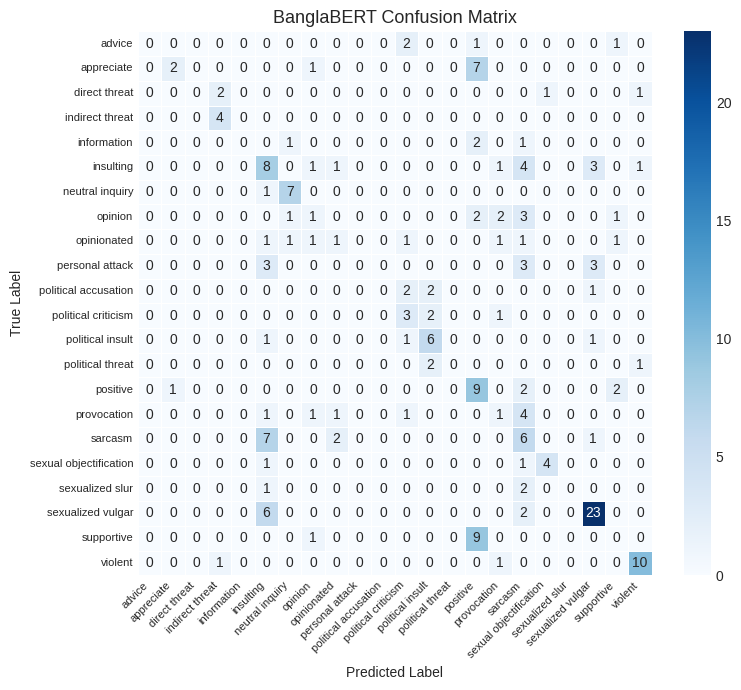

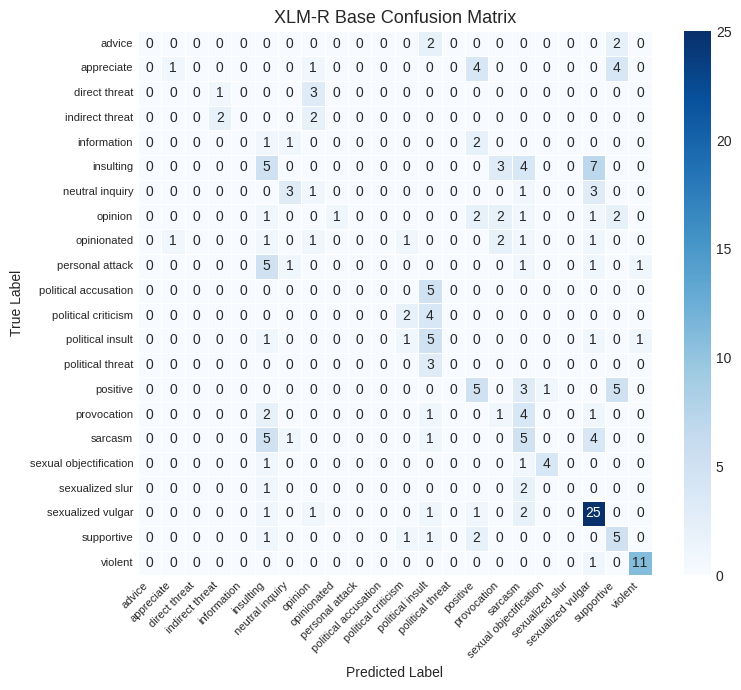

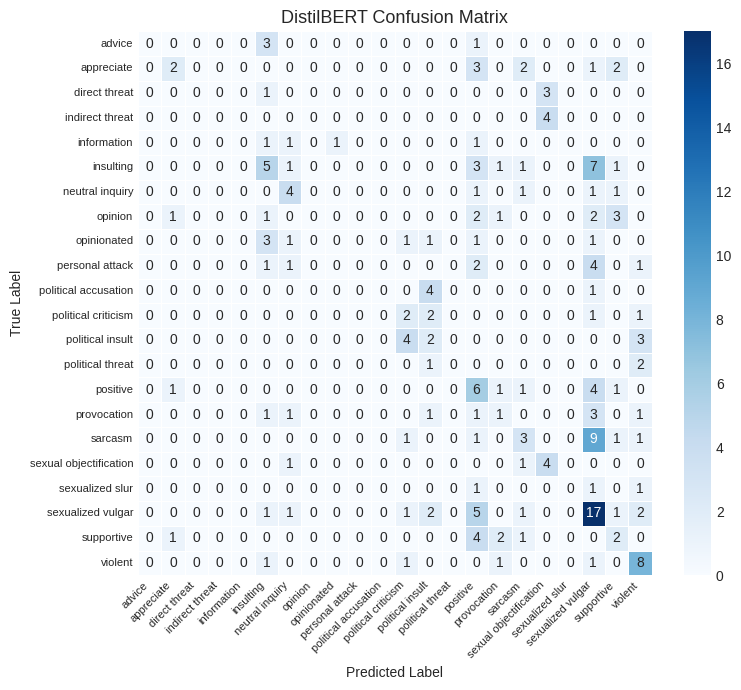

In [46]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix
import pandas as pd

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ==========================================
# CLASS NAMES
# ==========================================
class_names = [
    'advice', 'appreciate', 'direct threat', 'indirect threat', 'information',
    'insulting', 'neutral inquiry', 'opinion', 'opinionated', 'personal attack',
    'political accusation', 'political criticism', 'political insult',
    'political threat', 'positive', 'provocation', 'sarcasm',
    'sexual objectification', 'sexualized slur', 'sexualized vulgar',
    'supportive', 'violent'
]

# ==========================================
# PREDICTION FUNCTION
# ==========================================
def predict(model, loader):
    model.eval()
    y_true, y_pred = [], []

    with torch.no_grad():
        for batch in loader:
            input_ids = batch[0].to(device)
            attention_mask = batch[1].to(device)
            labels = batch[2].to(device)

            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            preds = torch.argmax(outputs.logits, dim=1)

            y_true.extend(labels.cpu().numpy())
            y_pred.extend(preds.cpu().numpy())

    return np.array(y_true), np.array(y_pred)

# ==========================================
# EVALUATION FUNCTION
# ==========================================
def evaluate(model, loader, name):
    y_true, y_pred = predict(model, loader)

    acc = accuracy_score(y_true, y_pred)
    p, r, f1, _ = precision_recall_fscore_support(y_true, y_pred, average="weighted")
    cm = confusion_matrix(y_true, y_pred)

    print(f"\n===== {name} =====")
    print(f"Accuracy : {acc:.4f}")
    print(f"Precision: {p:.4f}")
    print(f"Recall   : {r:.4f}")
    print(f"F1-score : {f1:.4f}")

    return acc, p, r, f1, cm

# ==========================================
# PAPER-STYLE CONFUSION MATRIX
# ==========================================
def plot_cm(cm, title):
    plt.style.use("seaborn-v0_8-white")

    plt.figure(figsize=(8, 7))  # slightly bigger for readability

    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        linewidths=0.5,
        linecolor='white',
        xticklabels=class_names,
        yticklabels=class_names,
        cbar=True
    )

    plt.title(title, fontsize=13)
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.xticks(rotation=45, ha='right', fontsize=8)
    plt.yticks(rotation=0, fontsize=8)

    plt.tight_layout()
    plt.show()

# ==========================================
# RUN EVALUATION
# ==========================================
bb = evaluate(model_bb, test_loader_bb, "BanglaBERT")
xlmr = evaluate(model_xlmr, test_loader_xlmr, "XLM-R Base")
distil = evaluate(model_distil, test_loader_distil, "DistilBERT")

# ==========================================
# FINAL COMPARISON TABLE
# ==========================================
results = pd.DataFrame([
    ["BanglaBERT", bb[0], bb[1], bb[2], bb[3]],
    ["XLM-R Base", xlmr[0], xlmr[1], xlmr[2], xlmr[3]],
    ["DistilBERT", distil[0], distil[1], distil[2], distil[3]],
], columns=["Model", "Accuracy", "Precision", "Recall", "F1"])

print("\n===== FINAL COMPARISON =====")
print(results)

# ==========================================
# CONFUSION MATRICES
# ==========================================
plot_cm(bb[4], "BanglaBERT Confusion Matrix")
plot_cm(xlmr[4], "XLM-R Base Confusion Matrix")
plot_cm(distil[4], "DistilBERT Confusion Matrix")

# Error Analysis

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/m

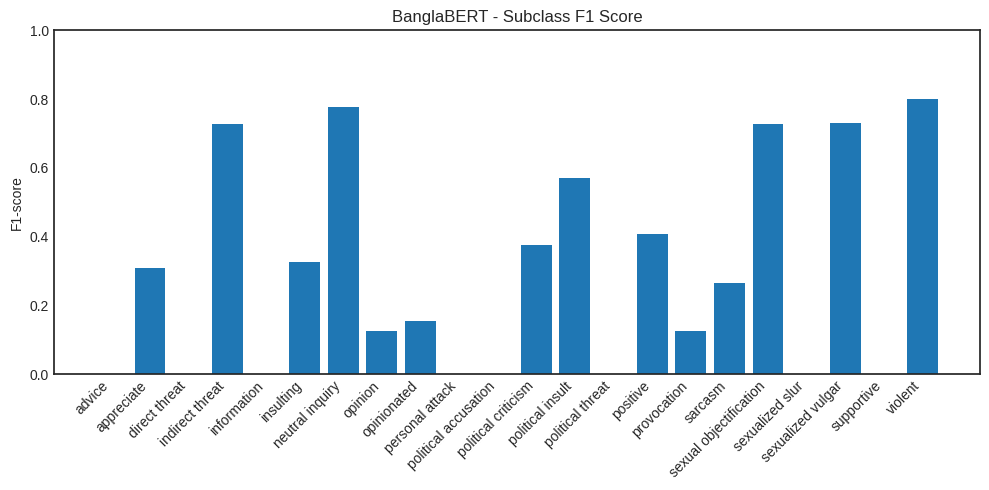

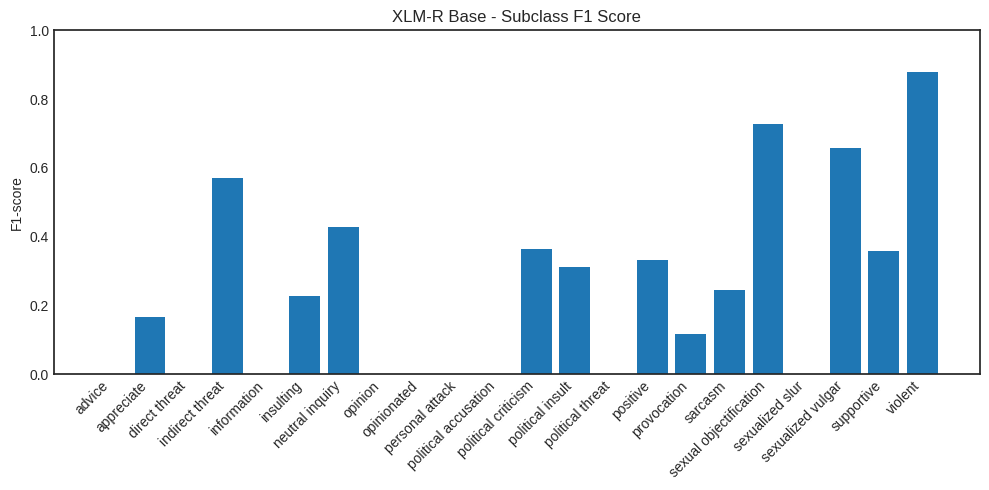

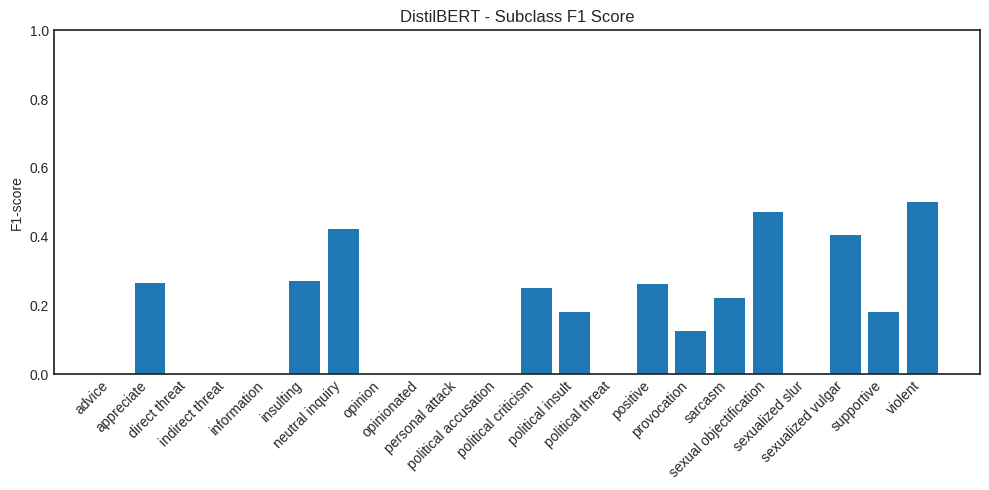

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


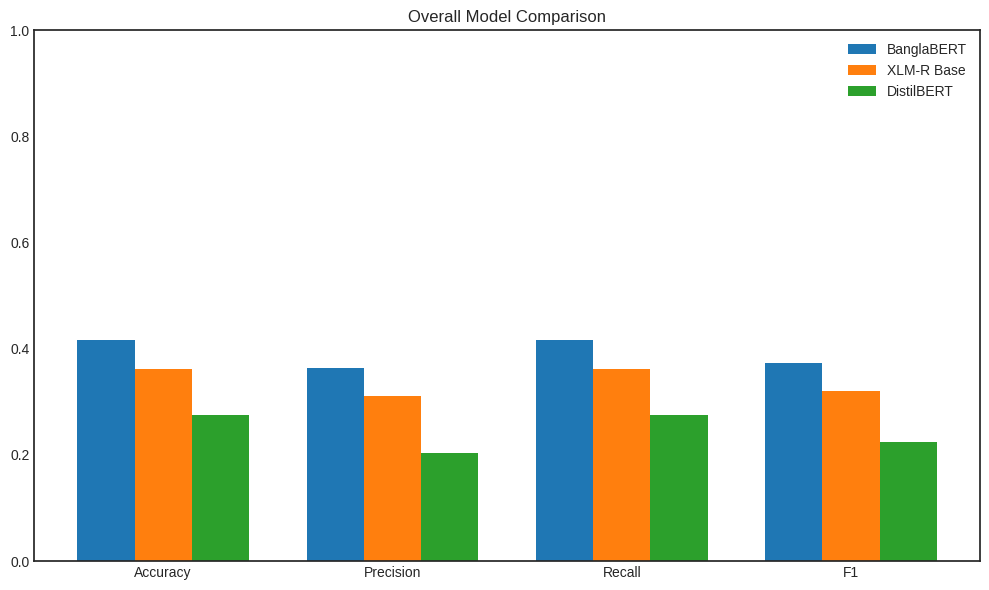

In [48]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, accuracy_score, precision_recall_fscore_support

# ==========================================
# CLASS NAMES
# ==========================================
class_names = [
    'advice', 'appreciate', 'direct threat', 'indirect threat', 'information',
    'insulting', 'neutral inquiry', 'opinion', 'opinionated', 'personal attack',
    'political accusation', 'political criticism', 'political insult',
    'political threat', 'positive', 'provocation', 'sarcasm',
    'sexual objectification', 'sexualized slur', 'sexualized vulgar',
    'supportive', 'violent'
]

# ==========================================
# PREDICTION FUNCTION
# (USE THIS IF NOT ALREADY CREATED)
# ==========================================
def predict(model, loader):
    model.eval()
    y_true, y_pred = [], []

    with torch.no_grad():
        for batch in loader:
            input_ids = batch[0].to(device)
            attention_mask = batch[1].to(device)
            labels = batch[2].to(device)

            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            preds = torch.argmax(outputs.logits, dim=1)

            y_true.extend(labels.cpu().numpy())
            y_pred.extend(preds.cpu().numpy())

    return np.array(y_true), np.array(y_pred)


# ==========================================
# GET SUBCLASS REPORT
# ==========================================
def get_class_report(y_true, y_pred):
    report = classification_report(
        y_true, y_pred,
        target_names=class_names,
        output_dict=True
    )
    return report


# ==========================================
# SUBCLASS F1 BAR CHART
# ==========================================
def plot_subclass_f1(report, title):
    f1_scores = [report[c]["f1-score"] for c in class_names]

    plt.figure(figsize=(10,5))
    plt.bar(class_names, f1_scores)
    plt.xticks(rotation=45, ha="right")
    plt.ylim(0, 1)
    plt.title(title)
    plt.ylabel("F1-score")
    plt.tight_layout()
    plt.show()


# ==========================================
# MODEL PREDICTIONS
# ==========================================
y_true_bb, y_pred_bb = predict(model_bb, test_loader_bb)
y_true_xlmr, y_pred_xlmr = predict(model_xlmr, test_loader_xlmr)
y_true_distil, y_pred_distil = predict(model_distil, test_loader_distil)

# ==========================================
# REPORTS
# ==========================================
report_bb = get_class_report(y_true_bb, y_pred_bb)
report_xlmr = get_class_report(y_true_xlmr, y_pred_xlmr)
report_distil = get_class_report(y_true_distil, y_pred_distil)

# ==========================================
# 1️⃣ SUBCLASS PERFORMANCE (SEPARATE PLOTS)
# ==========================================
plot_subclass_f1(report_bb, "BanglaBERT - Subclass F1 Score")
plot_subclass_f1(report_xlmr, "XLM-R Base - Subclass F1 Score")
plot_subclass_f1(report_distil, "DistilBERT - Subclass F1 Score")


# ==========================================
# 2️⃣ OVERALL MODEL COMPARISON BAR CHART
# ==========================================
def get_metrics(y_true, y_pred):
    acc = accuracy_score(y_true, y_pred)
    p, r, f1, _ = precision_recall_fscore_support(y_true, y_pred, average="weighted")
    return acc, p, r, f1


bb_metrics = get_metrics(y_true_bb, y_pred_bb)
xlmr_metrics = get_metrics(y_true_xlmr, y_pred_xlmr)
distil_metrics = get_metrics(y_true_distil, y_pred_distil)

metrics = ["Accuracy", "Precision", "Recall", "F1"]

x = np.arange(len(metrics))
width = 0.25

plt.figure(figsize=(10,6))

plt.bar(x - width, bb_metrics, width, label="BanglaBERT")
plt.bar(x, xlmr_metrics, width, label="XLM-R Base")
plt.bar(x + width, distil_metrics, width, label="DistilBERT")

plt.xticks(x, metrics)
plt.ylim(0, 1)
plt.title("Overall Model Comparison")
plt.legend()
plt.tight_layout()
plt.show()

# Logistic Regression

In [49]:
# ==========================================
# IMPORTS
# ==========================================
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score, precision_recall_fscore_support

# ==========================================
# DATA
# ==========================================
X_train, y_train = train_df['Description'], train_df['label']
X_val, y_val = val_df['Description'], val_df['label']
X_test, y_test = test_df['Description'], test_df['label']

# ==========================================
# TF-IDF
# ==========================================
vectorizer = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1,2),
    min_df=2,
    max_df=0.9
)

# Fit only on train
X_train_tfidf = vectorizer.fit_transform(X_train)

# Transform val + test
X_val_tfidf = vectorizer.transform(X_val)
X_test_tfidf = vectorizer.transform(X_test)

# ==========================================
# LOGISTIC REGRESSION
# ==========================================
clf = LogisticRegression(
    max_iter=3000,
    C=2.0,
    class_weight='balanced',
    n_jobs=-1
)

# Train
clf.fit(X_train_tfidf, y_train)

# ==========================================
# VALIDATION EVALUATION
# ==========================================
y_val_pred = clf.predict(X_val_tfidf)

val_acc = accuracy_score(y_val, y_val_pred)
val_precision, val_recall, val_f1, _ = precision_recall_fscore_support(
    y_val, y_val_pred, average='weighted', zero_division=0
)

print("\n📊 VALIDATION PERFORMANCE")
print(f"Accuracy : {val_acc:.4f}")
print(f"Precision: {val_precision:.4f}")
print(f"Recall   : {val_recall:.4f}")
print(f"F1-score : {val_f1:.4f}")

# ==========================================
# TEST EVALUATION
# ==========================================
y_test_pred = clf.predict(X_test_tfidf)

test_acc = accuracy_score(y_test, y_test_pred)
test_precision, test_recall, test_f1, _ = precision_recall_fscore_support(
    y_test, y_test_pred, average='weighted', zero_division=0
)

print("\n📊 TEST PERFORMANCE")
print(f"Accuracy : {test_acc:.4f}")
print(f"Precision: {test_precision:.4f}")
print(f"Recall   : {test_recall:.4f}")
print(f"F1-score : {test_f1:.4f}")

# ==========================================
# CLASSIFICATION REPORT (FIXED)
# ==========================================
class_names = le.classes_

print("\n🔹 Classification Report (Test):\n")
print(classification_report(y_test, y_test_pred, target_names=class_names, zero_division=0))

# ==========================================
# FINAL RESULTS (ADDED — SAME STYLE AS SVM)
# ==========================================
final_acc = test_acc
final_precision = test_precision
final_recall = test_recall
final_f1 = test_f1

print("\n🔥 FINAL MODEL PERFORMANCE (TF-IDF + Logistic Regression)")
print(f"Accuracy : {final_acc:.4f}")
print(f"Precision: {final_precision:.4f}")
print(f"Recall   : {final_recall:.4f}")
print(f"F1-score : {final_f1:.4f}")


📊 VALIDATION PERFORMANCE
Accuracy : 0.2317
Precision: 0.2997
Recall   : 0.2317
F1-score : 0.2362

📊 TEST PERFORMANCE
Accuracy : 0.2255
Precision: 0.3133
Recall   : 0.2255
F1-score : 0.2283

🔹 Classification Report (Test):

                        precision    recall  f1-score   support

                advice       0.00      0.00      0.00         4
            appreciate       0.43      0.30      0.35        10
         direct threat       0.17      0.50      0.25         4
       indirect threat       0.18      0.50      0.27         4
           information       0.05      0.25      0.08         4
             insulting       0.33      0.11      0.16        19
       neutral inquiry       0.25      0.38      0.30         8
               opinion       0.15      0.20      0.17        10
           opinionated       0.10      0.12      0.11         8
       personal attack       0.22      0.22      0.22         9
  political accusation       0.10      0.20      0.13         5
   poli

# SVM

In [51]:
# ==========================================
# IMPORTS
# ==========================================
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.metrics import classification_report, accuracy_score, precision_recall_fscore_support

# ==========================================
# DATA
# ==========================================
X_train, y_train = train_df['Description'], train_df['label']
X_val, y_val = val_df['Description'], val_df['label']
X_test, y_test = test_df['Description'], test_df['label']

# ==========================================
# TF-IDF
# ==========================================
vectorizer = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1,2),
    min_df=2,
    max_df=0.9
)

# Fit only on train
X_train_tfidf = vectorizer.fit_transform(X_train)

# Transform val + test
X_val_tfidf = vectorizer.transform(X_val)
X_test_tfidf = vectorizer.transform(X_test)

# ==========================================
# SVM MODEL
# ==========================================
svm_clf = LinearSVC(
    C=1.0,
    class_weight='balanced'
)

# Train
svm_clf.fit(X_train_tfidf, y_train)

# ==========================================
# VALIDATION EVALUATION
# ==========================================
y_val_pred = svm_clf.predict(X_val_tfidf)

val_acc = accuracy_score(y_val, y_val_pred)
val_precision, val_recall, val_f1, _ = precision_recall_fscore_support(
    y_val, y_val_pred, average='weighted', zero_division=0
)

print("\n📊 VALIDATION PERFORMANCE (SVM)")
print(f"Accuracy : {val_acc:.4f}")
print(f"Precision: {val_precision:.4f}")
print(f"Recall   : {val_recall:.4f}")
print(f"F1-score : {val_f1:.4f}")

# ==========================================
# TEST EVALUATION
# ==========================================
y_test_pred = svm_clf.predict(X_test_tfidf)

test_acc = accuracy_score(y_test, y_test_pred)
test_precision, test_recall, test_f1, _ = precision_recall_fscore_support(
    y_test, y_test_pred, average='weighted', zero_division=0
)

print("\n📊 TEST PERFORMANCE (SVM)")
print(f"Accuracy : {test_acc:.4f}")
print(f"Precision: {test_precision:.4f}")
print(f"Recall   : {test_recall:.4f}")
print(f"F1-score : {test_f1:.4f}")

# ==========================================
# CLASSIFICATION REPORT (FIXED)
# ==========================================
# Use LabelEncoder classes instead of hardcoded labels
class_names = le.classes_

print("\n🔹 Classification Report (Test):\n")
print(classification_report(y_test, y_test_pred, target_names=class_names, zero_division=0))

# ==========================================
# FINAL RESULTS
# ==========================================
final_acc = test_acc
final_precision = test_precision
final_recall = test_recall
final_f1 = test_f1

print("\n🔥 FINAL MODEL PERFORMANCE (TF-IDF + SVM)")
print(f"Accuracy : {final_acc:.4f}")
print(f"Precision: {final_precision:.4f}")
print(f"Recall   : {final_recall:.4f}")
print(f"F1-score : {final_f1:.4f}")


📊 VALIDATION PERFORMANCE (SVM)
Accuracy : 0.2195
Precision: 0.2881
Recall   : 0.2195
F1-score : 0.2362

📊 TEST PERFORMANCE (SVM)
Accuracy : 0.2157
Precision: 0.2877
Recall   : 0.2157
F1-score : 0.2291

🔹 Classification Report (Test):

                        precision    recall  f1-score   support

                advice       0.00      0.00      0.00         4
            appreciate       0.75      0.30      0.43        10
         direct threat       0.00      0.00      0.00         4
       indirect threat       0.25      0.50      0.33         4
           information       0.06      0.25      0.10         4
             insulting       0.27      0.16      0.20        19
       neutral inquiry       0.30      0.38      0.33         8
               opinion       0.14      0.20      0.17        10
           opinionated       0.09      0.12      0.11         8
       personal attack       0.20      0.22      0.21         9
  political accusation       0.10      0.20      0.13      

# Multinomial Naive Bayes

In [55]:
# ==========================================
# IMPORTS
# ==========================================
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, classification_report

# ==========================================
# DATA
# ==========================================
X_train, y_train = train_df['Description'], train_df['label']
X_val, y_val     = val_df['Description'], val_df['label']
X_test, y_test   = test_df['Description'], test_df['label']

# ==========================================
# TF-IDF (LIGHTWEIGHT)
# ==========================================
vectorizer = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1,2),
    min_df=2,
    max_df=0.9
)

X_train_tfidf = vectorizer.fit_transform(X_train)
X_val_tfidf   = vectorizer.transform(X_val)
X_test_tfidf  = vectorizer.transform(X_test)

# ==========================================
# MODEL (NAIVE BAYES)
# ==========================================
nb_model = MultinomialNB()

# ==========================================
# TRAIN
# ==========================================
nb_model.fit(X_train_tfidf, y_train)

# ==========================================
# VALIDATION EVALUATION
# ==========================================
y_val_pred = nb_model.predict(X_val_tfidf)

val_acc = accuracy_score(y_val, y_val_pred)
val_precision, val_recall, val_f1, _ = precision_recall_fscore_support(
    y_val, y_val_pred, average='weighted', zero_division=0
)

print("\n📊 VALIDATION PERFORMANCE (Naive Bayes)")
print(f"Accuracy : {val_acc:.4f}")
print(f"Precision: {val_precision:.4f}")
print(f"Recall   : {val_recall:.4f}")
print(f"F1-score : {val_f1:.4f}")

# ==========================================
# TEST EVALUATION
# ==========================================
y_test_pred = nb_model.predict(X_test_tfidf)

test_acc = accuracy_score(y_test, y_test_pred)
test_precision, test_recall, test_f1, _ = precision_recall_fscore_support(
    y_test, y_test_pred, average='weighted', zero_division=0
)

print("\n📊 TEST PERFORMANCE (Naive Bayes)")
print(f"Accuracy : {test_acc:.4f}")
print(f"Precision: {test_precision:.4f}")
print(f"Recall   : {test_recall:.4f}")
print(f"F1-score : {test_f1:.4f}")

# ==========================================
# CLASSIFICATION REPORT
# ==========================================
class_names = [
    'advice', 'appreciate', 'direct threat', 'indirect threat', 'information',
    'insulting', 'neutral inquiry', 'opinion', 'opinionated', 'personal attack',
    'political accusation', 'political criticism', 'political insult',
    'political threat', 'positive', 'provocation', 'sarcasm',
    'sexual objectification', 'sexualized slur', 'sexualized vulgar',
    'supportive', 'violent'
]


print("\n🔹 Classification Report (Test):\n")
print(classification_report(y_test, y_test_pred, target_names=class_names, zero_division=0))

# ==========================================
# FINAL RESULTS
# ==========================================
print("\n🔥 FINAL MODEL PERFORMANCE (TF-IDF + Naive Bayes)")
print(f"Accuracy : {test_acc:.4f}")
print(f"Precision: {test_precision:.4f}")
print(f"Recall   : {test_recall:.4f}")
print(f"F1-score : {test_f1:.4f}")


📊 VALIDATION PERFORMANCE (Naive Bayes)
Accuracy : 0.1707
Precision: 0.0992
Recall   : 0.1707
F1-score : 0.0800

📊 TEST PERFORMANCE (Naive Bayes)
Accuracy : 0.1863
Precision: 0.1466
Recall   : 0.1863
F1-score : 0.1004

🔹 Classification Report (Test):

                        precision    recall  f1-score   support

                advice       0.00      0.00      0.00         4
            appreciate       1.00      0.20      0.33        10
         direct threat       0.00      0.00      0.00         4
       indirect threat       0.00      0.00      0.00         4
           information       0.00      0.00      0.00         4
             insulting       0.20      0.11      0.14        19
       neutral inquiry       0.00      0.00      0.00         8
               opinion       0.00      0.00      0.00        10
           opinionated       0.00      0.00      0.00         8
       personal attack       0.00      0.00      0.00         9
  political accusation       0.00      0.00

# DL Models

In [62]:
# ==========================================
# CNN, BiLSTM, CNN+BiLSTM WITH FASTTEXT
# ==========================================

import numpy as np
import pandas as pd
import tensorflow as tf
import fasttext

from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, classification_report

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.layers import Input, Embedding, Conv1D, GlobalMaxPooling1D
from tensorflow.keras.layers import Dense, Dropout, Bidirectional, LSTM, MaxPooling1D
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping


# ==========================================
# DATA
# ==========================================
X_train = train_df["Description"].astype(str).values
y_train = train_df["label"].values

X_val = val_df["Description"].astype(str).values
y_val = val_df["label"].values

X_test = test_df["Description"].astype(str).values
y_test = test_df["label"].values


# ==========================================
# TOKENIZATION + PADDING
# ==========================================
max_words = 20000
max_len = 150
embedding_dim = 300

tokenizer = Tokenizer(num_words=max_words, oov_token="<OOV>")
tokenizer.fit_on_texts(X_train)

X_train_pad = pad_sequences(tokenizer.texts_to_sequences(X_train), maxlen=max_len, padding="post")
X_val_pad   = pad_sequences(tokenizer.texts_to_sequences(X_val), maxlen=max_len, padding="post")
X_test_pad  = pad_sequences(tokenizer.texts_to_sequences(X_test), maxlen=max_len, padding="post")

num_classes = len(np.unique(y_train))
print("Number of Classes:", num_classes)


# ==========================================
# CLASS WEIGHTS
# ==========================================
classes = np.unique(y_train)
class_weights = dict(zip(classes, compute_class_weight("balanced", classes=classes, y=y_train)))


# ==========================================
# ✅ FIX: TRAIN FASTTEXT MODEL (instead of loading .xlsx)
# ==========================================

# Convert training data to fasttext format
with open("ft_train.txt", "w", encoding="utf-8") as f:
    for text, label in zip(X_train, y_train):
        f.write(f"__label__{label} {text}\n")

# Train fasttext model
ft_model = fasttext.train_supervised(
    input="ft_train.txt",
    dim=embedding_dim,
    epoch=20,
    lr=0.5,
    wordNgrams=2
)


# ==========================================
# EMBEDDING MATRIX
# ==========================================
word_index = tokenizer.word_index
embedding_matrix = np.zeros((max_words, embedding_dim))

for word, i in word_index.items():
    if i < max_words:
        embedding_matrix[i] = ft_model.get_word_vector(word)


# ==========================================
# EARLY STOPPING
# ==========================================
early_stop = EarlyStopping(monitor="val_loss", patience=2, restore_best_weights=True)


# ==========================================
# MODEL BUILDER
# ==========================================
def create_model(model_type="cnn"):
    inp = Input(shape=(max_len,))

    x = Embedding(
        input_dim=max_words,
        output_dim=embedding_dim,
        weights=[embedding_matrix],
        trainable=False
    )(inp)

    if model_type == "cnn":
        x = Conv1D(128, 5, activation="relu")(x)
        x = GlobalMaxPooling1D()(x)

    elif model_type == "bilstm":
        x = Bidirectional(LSTM(64))(x)

    elif model_type == "hybrid":
        x = Conv1D(128, 5, activation="relu", padding="same")(x)
        x = MaxPooling1D(2)(x)
        x = Bidirectional(LSTM(64))(x)

    x = Dropout(0.5)(x)
    x = Dense(64, activation="relu")(x)
    out = Dense(num_classes, activation="softmax")(x)

    model = Model(inp, out)
    model.compile(
        loss="sparse_categorical_crossentropy",
        optimizer="adam",
        metrics=["accuracy"]
    )
    return model


# ==========================================
# EVALUATION FUNCTION
# ==========================================
def evaluate(model, name):
    pred = np.argmax(model.predict(X_test_pad), axis=1)

    acc = accuracy_score(y_test, pred)
    p, r, f1, _ = precision_recall_fscore_support(y_test, pred, average="weighted")

    print(f"\n===== {name.upper()} =====")
    print("Accuracy:", acc)
    print("Precision:", p)
    print("Recall:", r)
    print("F1:", f1)
    print(classification_report(y_test, pred))

    return acc, p, r, f1


# ==========================================
# TRAIN MODELS
# ==========================================
results = []

for name in ["cnn", "bilstm", "hybrid"]:
    print("\nTraining:", name.upper())

    model = create_model(name)

    model.fit(
        X_train_pad, y_train,
        validation_data=(X_val_pad, y_val),
        epochs=5,
        batch_size=32,
        class_weight=class_weights,
        callbacks=[early_stop],
        verbose=1
    )

    results.append((name, *evaluate(model, name)))


# ==========================================
# FINAL RESULT TABLE
# ==========================================
print("\nFINAL RESULTS")
print(pd.DataFrame(results, columns=["Model", "Accuracy", "Precision", "Recall", "F1"]))

Number of Classes: 22


Read 0M words
Number of words:  4366
Number of labels: 22
Progress:  74.6% words/sec/thread:  267571 lr:  0.126929 avg.loss:  1.819244 ETA:   0h 0m 0s


Training: CNN
Epoch 1/5


Progress: 100.0% words/sec/thread:  239184 lr:  0.000000 avg.loss:  1.511384 ETA:   0h 0m 0s


23/23 ━━━━━━━━━━━━━━━━━━━━ 5s 109ms/step - accuracy: 0.1844 - loss: 2.9824 - val_accuracy: 0.2683 - val_loss: 2.7309
Epoch 2/5
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.3514 - loss: 2.6072 - val_accuracy: 0.3049 - val_loss: 2.5502
Epoch 3/5
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.4783 - loss: 2.3126 - val_accuracy: 0.3049 - val_loss: 2.3854
Epoch 4/5
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.5777 - loss: 2.1145 - val_accuracy: 0.3415 - val_loss: 2.3580
Epoch 5/5
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.5883 - loss: 1.8634 - val_accuracy: 0.2927 - val_loss: 2.3645
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 59ms/step

===== CNN =====
Accuracy: 0.30392156862745096
Precision: 0.329947661972323
Recall: 0.30392156862745096
F1: 0.3083406675903774
              precision    recall  f1-score   support

           0       0.12      0.25      0.17         4
           1       0.08      0.10      0.09        10
           2       0.33      0.25      0.29         4
 

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/m

23/23 ━━━━━━━━━━━━━━━━━━━━ 3s 39ms/step - accuracy: 0.1374 - loss: 2.9816 - val_accuracy: 0.2561 - val_loss: 2.9613
Epoch 2/5
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.3329 - loss: 2.9342 - val_accuracy: 0.2439 - val_loss: 2.6303
Epoch 3/5
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.3347 - loss: 2.5030 - val_accuracy: 0.2805 - val_loss: 2.4033
Epoch 4/5
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.4656 - loss: 2.2097 - val_accuracy: 0.3049 - val_loss: 2.4719
Epoch 5/5
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.5631 - loss: 1.8225 - val_accuracy: 0.2927 - val_loss: 2.5258
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step

===== BILSTM =====
Accuracy: 0.23039215686274508
Precision: 0.23837655680216233
Recall: 0.23039215686274508
F1: 0.19423571094170314
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         4
           1       0.00      0.00      0.00        10
           2       0.00      0.00      0.00   

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/m

23/23 ━━━━━━━━━━━━━━━━━━━━ 3s 36ms/step - accuracy: 0.1153 - loss: 3.0788 - val_accuracy: 0.1463 - val_loss: 2.9616
Epoch 2/5
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.2543 - loss: 2.6948 - val_accuracy: 0.2195 - val_loss: 2.5900
Epoch 3/5
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.3960 - loss: 2.4041 - val_accuracy: 0.2927 - val_loss: 2.4295
Epoch 4/5
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.5925 - loss: 1.7604 - val_accuracy: 0.3171 - val_loss: 2.3920
Epoch 5/5
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.6954 - loss: 1.4259 - val_accuracy: 0.2927 - val_loss: 2.4829
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step

===== HYBRID =====
Accuracy: 0.29901960784313725
Precision: 0.35977139370305455
Recall: 0.29901960784313725
F1: 0.3069495871150538
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         4
           1       0.12      0.10      0.11        10
           2       0.20      0.25      0.22    

In [58]:
df.to_csv('/kaggle/working/final_labeled_dataset.csv', index=False)